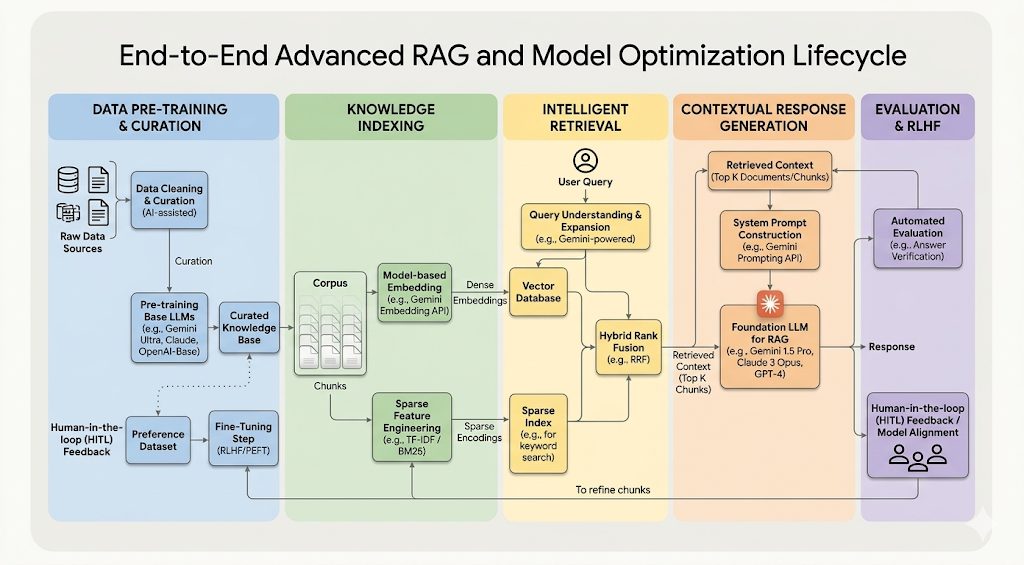

# Contextual Retrieval: A Preprocessing Framework for Enhanced Information Retrieval in Retrieval-Augmented Generation Systems

---

## Abstract

Retrieval-Augmented Generation (RAG) has become the dominant paradigm for grounding large language models (LLMs) in domain-specific knowledge. However, conventional RAG pipelines suffer from a critical failure mode: the **destruction of contextual semantics** during the chunking phase, leading to retrieval degradation when individual text fragments lack sufficient disambiguating information. This report presents **Contextual Retrieval**, a preprocessing methodology that augments each chunk with concise, document-aware contextual descriptors prior to embedding and lexical indexing. The framework introduces two complementary sub-techniques—**Contextual Embeddings** and **Contextual BM25**—which, when combined with a reranking stage, reduce the top-20-chunk retrieval failure rate by **67%** (from $5.7\%$ to $1.9\%$). We formalize the mathematical underpinnings, describe the architectural pipeline, analyze cost-performance tradeoffs, and present comprehensive empirical results across heterogeneous knowledge domains.

---

## 1. Introduction and Problem Formulation

### 1.1 Motivation

For an LLM $\mathcal{M}$ to generate contextually accurate responses in domain-specific applications—customer support, legal analysis, biomedical question answering—it requires access to an external knowledge base $\mathcal{K}$ that supplements its parametric knowledge $\theta_{\mathcal{M}}$. The standard mechanism for achieving this is **Retrieval-Augmented Generation (RAG)**, wherein relevant passages are retrieved from $\mathcal{K}$ and concatenated with the user query $q$ to form the augmented prompt.

Formally, given a query $q$ and a knowledge corpus $\mathcal{K} = \{d_1, d_2, \ldots, d_N\}$, the RAG objective is to identify a subset $\mathcal{S} \subset \mathcal{K}$ such that:

$$
\mathcal{S}^* = \arg\max_{\mathcal{S} \subseteq \mathcal{K}, |\mathcal{S}| = K} \; \text{Relevance}(q, \mathcal{S})
$$

where $K$ is the number of retrieved chunks and $\text{Relevance}(\cdot, \cdot)$ quantifies the utility of the retrieved set for answering $q$.

### 1.2 The Context Destruction Problem

Standard RAG pipelines partition each document $d_i$ into a set of chunks $\{c_{i,1}, c_{i,2}, \ldots, c_{i,m_i}\}$, typically bounded to a few hundred tokens. This chunking operation, while necessary for retrieval granularity and computational tractability, introduces a fundamental information-theoretic loss:

$$
I(c_{i,j}; q) \ll I(c_{i,j} \mid d_i; q)
$$

That is, the mutual information between an isolated chunk $c_{i,j}$ and a query $q$ is substantially lower than the mutual information conditioned on the full document context $d_i$. Critical disambiguating signals—entity references, temporal anchors, causal relationships—are stripped during chunking, rendering semantically relevant chunks **irretrievable** under both dense and sparse retrieval paradigms.

**Example.** Consider the chunk:

> *"The company's revenue grew by 3% over the previous quarter."*

Without the parent document context, neither the **entity** (which company) nor the **temporal frame** (which quarter) is recoverable, causing retrieval failure for the query *"What was the revenue growth for ACME Corp in Q2 2023?"*

### 1.3 Contributions

This report formalizes and evaluates **Contextual Retrieval**, a framework that:

1. **Prepends chunk-specific contextual descriptors** generated by an LLM to each chunk prior to embedding and indexing.
2. **Applies this contextualization to both dense (embedding) and sparse (BM25) retrieval channels**, yielding Contextual Embeddings and Contextual BM25.
3. **Integrates a reranking stage** to further refine retrieval precision.
4. **Demonstrates cumulative performance gains** of up to 67% reduction in retrieval failure rate across diverse knowledge domains.

---

## 2. Foundations: Retrieval Mechanisms in RAG

### 2.1 Dense Retrieval via Semantic Embeddings

Dense retrieval maps both queries and chunks into a shared $d$-dimensional vector space $\mathbb{R}^d$ via an embedding function $\phi: \mathcal{T} \rightarrow \mathbb{R}^d$, where $\mathcal{T}$ is the space of token sequences.

For a query $q$ and chunk $c$, the relevance score under dense retrieval is computed as the cosine similarity:

$$
\text{sim}_{\text{dense}}(q, c) = \frac{\phi(q)^\top \phi(c)}{\|\phi(q)\| \cdot \|\phi(c)\|}
$$

Dense models excel at capturing **semantic similarity**—paraphrases, synonyms, and conceptual relatedness—but are prone to missing **exact lexical matches** for identifiers, error codes, proper nouns, and domain-specific terminology.

### 2.2 Sparse Retrieval via BM25

**BM25 (Best Matching 25)** is a probabilistic ranking function rooted in the TF-IDF framework, designed for precise lexical matching.

#### 2.2.1 TF-IDF Foundation

Term Frequency–Inverse Document Frequency assigns a weight to term $t$ in document $d$ within a corpus $\mathcal{D}$ as:

$$
\text{TF-IDF}(t, d, \mathcal{D}) = \text{TF}(t, d) \times \text{IDF}(t, \mathcal{D})
$$

where:

$$
\text{TF}(t, d) = \frac{f_{t,d}}{\sum_{t' \in d} f_{t',d}}
$$

$$
\text{IDF}(t, \mathcal{D}) = \log \frac{|\mathcal{D}|}{|\{d \in \mathcal{D} : t \in d\}|}
$$

Here, $f_{t,d}$ denotes the raw frequency of term $t$ in document $d$, and $|\mathcal{D}|$ is the total number of documents.

#### 2.2.2 BM25 Scoring Function

BM25 refines TF-IDF by introducing **term frequency saturation** and **document length normalization**. For a query $q = \{t_1, t_2, \ldots, t_n\}$ and a chunk $c$, the BM25 score is:

$$
\text{BM25}(q, c) = \sum_{i=1}^{n} \text{IDF}(t_i) \cdot \frac{f_{t_i, c} \cdot (k_1 + 1)}{f_{t_i, c} + k_1 \cdot \left(1 - b + b \cdot \frac{|c|}{|c|_{\text{avg}}}\right)}
$$

where:

| Symbol | Definition |
|--------|-----------|
| $f_{t_i, c}$ | Frequency of term $t_i$ in chunk $c$ |
| $\|c\|$ | Length of chunk $c$ (in tokens) |
| $\|c\|_{\text{avg}}$ | Average chunk length across the corpus |
| $k_1$ | Term frequency saturation parameter (typically $k_1 \in [1.2, 2.0]$) |
| $b$ | Length normalization parameter (typically $b = 0.75$) |

The **saturation function** $\frac{f \cdot (k_1 + 1)}{f + k_1 \cdot (\cdots)}$ ensures that the marginal contribution of additional term occurrences diminishes, preventing common terms from dominating the relevance score.

**Why BM25 complements embeddings.** Consider the query *"Error code TS-999"*. A dense embedding model may retrieve chunks discussing error codes generically (high semantic overlap), whereas BM25 directly matches the exact string `TS-999`, yielding precise retrieval.

### 2.3 Hybrid Retrieval via Rank Fusion

A hybrid retrieval system combines the outputs of both dense and sparse retrievers. Let $\mathcal{R}_{\text{dense}}(q)$ and $\mathcal{R}_{\text{BM25}}(q)$ denote the ranked lists from each retriever. The standard approach is **Reciprocal Rank Fusion (RRF)**:

$$
\text{RRF}(c) = \sum_{r \in \{\text{dense}, \text{BM25}\}} \frac{1}{k_{\text{rrf}} + \text{rank}_r(c)}
$$

where $\text{rank}_r(c)$ is the rank of chunk $c$ in retriever $r$'s output, and $k_{\text{rrf}}$ is a smoothing constant (typically $k_{\text{rrf}} = 60$). Chunks are then re-sorted by their fused score, and the top-$K$ are selected.

### 2.4 Standard RAG Pipeline

The complete preprocessing and runtime pipeline for hybrid RAG is:

**Preprocessing (Offline):**
1. Partition the corpus $\mathcal{K}$ into chunks: $\mathcal{C} = \{c_1, c_2, \ldots, c_M\}$.
2. Compute dense embeddings: $\{\phi(c_j)\}_{j=1}^{M}$; store in a vector database.
3. Build a BM25 inverted index over $\mathcal{C}$.

**Inference (Online):**
1. Receive user query $q$.
2. Retrieve top-$N_{\text{dense}}$ chunks via dense similarity: $\mathcal{R}_{\text{dense}}(q)$.
3. Retrieve top-$N_{\text{BM25}}$ chunks via BM25: $\mathcal{R}_{\text{BM25}}(q)$.
4. Apply rank fusion and deduplication → top-$K$ chunks $\mathcal{S}$.
5. Construct the augmented prompt: $p = [q \oplus \mathcal{S}]$.
6. Generate response: $y = \mathcal{M}(p; \theta)$.

---

## 3. Contextual Retrieval: Methodology

### 3.1 Core Insight

The central thesis of Contextual Retrieval is that the information loss incurred during chunking can be **partially recovered** by conditioning each chunk on its parent document context via an LLM-generated contextual preamble.

Define a **contextualizer function** $\mathcal{G}$:

$$
\mathcal{G}: (d_i, c_{i,j}) \mapsto \hat{c}_{i,j} = [\text{ctx}(d_i, c_{i,j}) \oplus c_{i,j}]
$$

where $\text{ctx}(d_i, c_{i,j})$ is a concise (typically 50–100 tokens) natural-language descriptor that situates chunk $c_{i,j}$ within the semantics of its parent document $d_i$, and $\oplus$ denotes concatenation.

### 3.2 Contextual Embeddings

After contextualization, the embedding of each chunk incorporates the disambiguating context:

$$
\phi(\hat{c}_{i,j}) = \phi\big(\text{ctx}(d_i, c_{i,j}) \oplus c_{i,j}\big)
$$

Because transformer-based embedding models compute contextual representations over the full input sequence, the prepended context propagates through the self-attention mechanism, enriching the chunk's vector representation with entity, temporal, and relational information from the parent document.

### 3.3 Contextual BM25

Similarly, the BM25 index is built over the contextualized chunks $\{\hat{c}_{i,j}\}$ rather than the raw chunks $\{c_{i,j}\}$. This introduces additional discriminative terms (e.g., entity names, date references) into the lexical index, enabling BM25 to match queries that reference specific entities or time frames absent from the original chunk text.

Formally:

$$
\text{BM25}_{\text{ctx}}(q, \hat{c}_{i,j}) = \sum_{t \in q} \text{IDF}(t) \cdot \frac{f_{t, \hat{c}_{i,j}} \cdot (k_1 + 1)}{f_{t, \hat{c}_{i,j}} + k_1 \cdot \left(1 - b + b \cdot \frac{|\hat{c}_{i,j}|}{|\hat{c}|_{\text{avg}}}\right)}
$$

The key difference from standard BM25 is that $f_{t, \hat{c}_{i,j}}$ now includes term frequencies from **both** the original chunk content and the prepended context, expanding the lexical surface area available for matching.

### 3.4 Contextualization via LLM

The contextualizer $\mathcal{G}$ is implemented as an LLM inference call. The prompt template provided to the model (Claude 3 Haiku in the reference implementation) is:

```xml
<document>
{{WHOLE_DOCUMENT}}
</document>
Here is the chunk we want to situate within the whole document
<chunk>
{{CHUNK_CONTENT}}
</chunk>
Please give a short succinct context to situate this chunk within
the overall document for the purposes of improving search retrieval
of the chunk. Answer only with the succinct context and nothing else.
```

**Transformation Example:**

| | Content |
|---|---------|
| **Original Chunk** | *"The company's revenue grew by 3% over the previous quarter."* |
| **Contextualized Chunk** | *"This chunk is from an SEC filing on ACME Corp's performance in Q2 2023; the previous quarter's revenue was \$314 million. The company's revenue grew by 3% over the previous quarter."* |

The generated context resolves the **entity ambiguity** (ACME Corp), **temporal ambiguity** (Q2 2023), and **numerical reference frame** (\$314M baseline), thereby enabling both dense and sparse retrievers to match the chunk against entity- and time-specific queries.

### 3.5 Complete Contextual Retrieval Pipeline

**Preprocessing (Offline):**

```
1. For each document d_i ∈ K:
   a. Partition d_i into chunks: {c_{i,1}, ..., c_{i,m_i}}
   b. For each chunk c_{i,j}:
      i.   Generate context: ctx(d_i, c_{i,j}) ← G(d_i, c_{i,j})
      ii.  Form contextualized chunk: ĉ_{i,j} = ctx ⊕ c_{i,j}
      iii. Compute embedding: φ(ĉ_{i,j})
      iv.  Index ĉ_{i,j} in BM25 inverted index
   c. Store embeddings in vector database
```

**Inference (Online):**

```
1. Receive query q
2. Dense retrieval:    R_dense(q)  ← top-N by cosine similarity on φ(ĉ)
3. Sparse retrieval:   R_BM25(q)   ← top-N by BM25_ctx(q, ĉ)
4. Rank fusion:        S           ← RRF(R_dense ∪ R_BM25), take top-K
5. (Optional) Rerank:  S'          ← Reranker(q, S), take top-K'
6. Generate:           y           ← M(q ⊕ S'; θ)
```

---

## 4. Cost Optimization via Prompt Caching

### 4.1 The Computational Challenge

Naive implementation of contextualization requires passing the **entire parent document** $d_i$ alongside each chunk $c_{i,j}$ to the LLM, resulting in a total token cost that scales as:

$$
\text{Cost}_{\text{naive}} = \sum_{i=1}^{N} m_i \cdot (|d_i| + |c_{i,j}| + |p_{\text{instr}}|) \cdot \rho_{\text{input}} + |o_{i,j}| \cdot \rho_{\text{output}}
$$

where $|p_{\text{instr}}|$ is the instruction prompt length, $|o_{i,j}|$ is the output context length, and $\rho_{\text{input}}, \rho_{\text{output}}$ are per-token costs.

### 4.2 Prompt Caching Optimization

**Prompt caching** eliminates redundant processing of the document prefix. For a document $d_i$ with $m_i$ chunks, the document content is loaded into the KV-cache once. Subsequent contextualization calls for chunks $c_{i,2}, \ldots, c_{i,m_i}$ reference the cached document representation, paying only for the incremental chunk-specific tokens.

The amortized cost reduces to:

$$
\text{Cost}_{\text{cached}} = \sum_{i=1}^{N} \left[ |d_i| \cdot \rho_{\text{cache\_write}} + m_i \cdot \left( |c_{i,j}| \cdot \rho_{\text{cache\_read}} + |o_{i,j}| \cdot \rho_{\text{output}} \right) \right]
$$

Under representative parameter assumptions:

| Parameter | Value |
|-----------|-------|
| Average chunk size $\|c\|$ | 800 tokens |
| Average document size $\|d\|$ | 8,000 tokens |
| Instruction prompt $\|p_{\text{instr}}\|$ | 50 tokens |
| Generated context $\|o\|$ | 100 tokens |

The one-time contextualization cost is approximately **\$1.02 per million document tokens**, representing a substantial reduction relative to naive per-chunk document re-processing.

### 4.3 Latency Reduction

Prompt caching yields a latency reduction of $> 2\times$ per contextualization call, as the cached document prefix does not require re-computation of attention and feedforward layers across the transformer stack.

---

## 5. Reranking: Second-Stage Precision Refinement

### 5.1 Motivation

Initial retrieval (both dense and sparse) is optimized for **recall**—surfacing a broad candidate set—at the expense of precision. When the candidate set $\mathcal{S}$ is large (e.g., $|\mathcal{S}| = 150$), many chunks are marginally relevant or irrelevant, introducing noise into the generation context.

### 5.2 Cross-Encoder Reranking

A **reranking model** $\mathcal{R}_{\text{rerank}}: (q, c) \mapsto s \in \mathbb{R}$ provides a fine-grained relevance score by jointly encoding the query-chunk pair through a cross-encoder architecture. Unlike bi-encoder retrieval (which independently encodes $q$ and $c$), the cross-encoder computes full cross-attention:

$$
s_{\text{rerank}}(q, c) = \sigma\left(W^\top \cdot \text{CLS}\big(\text{Transformer}([q; \text{[SEP]}; c])\big)\right)
$$

where $\sigma$ is a sigmoid activation, $W$ is a learned projection, and $\text{CLS}(\cdot)$ extracts the classification token representation.

### 5.3 Reranking Pipeline Integration

The two-stage retrieval-reranking protocol proceeds as:

1. **Stage 1 — Broad Retrieval:** Retrieve top-$N$ candidates ($N = 150$) using hybrid dense + BM25 retrieval.
2. **Stage 2 — Precision Refinement:** Score all $N$ candidates using the cross-encoder reranker; select top-$K$ ($K = 20$) by reranker score.
3. **Generation:** Pass the refined top-$K$ chunks to the generative model.

This architecture exploits the **efficiency** of bi-encoder retrieval at Stage 1 (sub-linear search via approximate nearest neighbors) and the **accuracy** of cross-encoder scoring at Stage 2 (applied only to a tractable candidate set).

### 5.4 Latency-Accuracy Tradeoff

Reranking introduces an additional inference step at runtime. The latency overhead is:

$$
\Delta t_{\text{rerank}} = N \cdot t_{\text{cross-enc}} / P
$$

where $t_{\text{cross-enc}}$ is the per-pair cross-encoder inference time and $P$ is the degree of parallelism. Since reranking is embarrassingly parallel across chunks, the wall-clock overhead is manageable for $N \leq 200$ with modern GPU inference infrastructure.

---

## 6. Experimental Methodology

### 6.1 Evaluation Domains

Experiments were conducted across **four heterogeneous knowledge domains** to assess generalization:

| Domain | Characteristics |
|--------|----------------|
| **Codebases** | Structured, identifier-heavy, syntactic patterns |
| **Fiction** | Narrative, entity-dense, coreference-heavy |
| **ArXiv Papers** | Technical, equation-rich, citation-dense |
| **Science Papers** | Experimental, methodology-specific, terminology-dense |

### 6.2 Embedding Models

Multiple embedding providers were evaluated:

- **Gemini Text 004** (top-performing)
- **Voyage AI** embeddings
- Additional proprietary and open-source models

### 6.3 Evaluation Metric

The primary metric is **1 − Recall@K**, measuring the fraction of relevant documents that **fail** to appear in the top-$K$ retrieved chunks:

$$
1 - \text{Recall@}K = 1 - \frac{|\mathcal{R}_{\text{relevant}} \cap \mathcal{R}_{\text{top-}K}|}{|\mathcal{R}_{\text{relevant}}|}
$$

where $\mathcal{R}_{\text{relevant}}$ is the set of ground-truth relevant chunks and $\mathcal{R}_{\text{top-}K}$ is the set of top-$K$ retrieved chunks.

Lower values of $1 - \text{Recall@}K$ indicate better retrieval performance (fewer failures).

### 6.4 Experimental Conditions

The following retrieval configurations were systematically compared:

| Configuration | Dense | BM25 | Contextualized | Reranked |
|--------------|-------|------|----------------|----------|
| Baseline Embeddings | ✓ | ✗ | ✗ | ✗ |
| Embeddings + BM25 | ✓ | ✓ | ✗ | ✗ |
| Contextual Embeddings | ✓ | ✗ | ✓ | ✗ |
| Contextual Embeddings + Contextual BM25 | ✓ | ✓ | ✓ | ✗ |
| Contextual Embeddings + Contextual BM25 + Reranking | ✓ | ✓ | ✓ | ✓ |

All experiments used $K = 20$ for the primary evaluation (with ablations at $K \in \{5, 10, 20\}$), the Gemini Text 004 embedding model, and the Cohere reranker.

---

## 7. Results

### 7.1 Retrieval Failure Rate Reduction

The following table summarizes the top-20-chunk retrieval failure rates ($1 - \text{Recall@}20$) averaged across all knowledge domains, using the best-performing embedding model (Gemini Text 004):

| Method | Failure Rate | Relative Reduction |
|--------|:------------:|:-------------------:|
| Baseline (Embeddings only) | $5.7\%$ | — |
| Contextual Embeddings | $3.7\%$ | $\mathbf{35\%}$ |
| Contextual Embeddings + Contextual BM25 | $2.9\%$ | $\mathbf{49\%}$ |
| Contextual Embeddings + Contextual BM25 + Reranking | $1.9\%$ | $\mathbf{67\%}$ |

### 7.2 Key Findings

The empirical results yield the following principal conclusions, ordered by effect magnitude:

1. **Hybrid retrieval (Embeddings + BM25) consistently outperforms embeddings alone.** Lexical matching captures exact-match signals that dense representations fail to encode.

2. **Contextual Embeddings alone reduce failure rate by 35%.** The prepended context enriches the embedding vector with disambiguating entity, temporal, and relational signals.

3. **Contextual BM25 provides additive gains beyond Contextual Embeddings.** Combining both channels reduces failure rate by 49%, confirming that dense and sparse signals remain complementary even after contextualization.

4. **Reranking provides further precision refinement**, achieving a cumulative 67% failure rate reduction. The cross-encoder's full cross-attention mechanism captures fine-grained query-chunk relevance that bi-encoder retrieval and BM25 cannot model.

5. **All benefits are stackable.** The optimal configuration combines Contextual Embeddings (Voyage or Gemini) + Contextual BM25 + Reranking + top-20 chunk delivery.

6. **Top-20 retrieval outperforms top-10 and top-5.** Increasing $K$ raises recall at the cost of potential context dilution; however, at $K = 20$, the recall gains dominate.

7. **Contextualization improves performance across all embedding models tested**, though the magnitude of improvement varies by model.

### 7.3 Performance Progression Visualization

The cumulative improvement can be expressed as a monotonically decreasing failure rate:

$$
\underbrace{5.7\%}_{\text{Baseline}} \xrightarrow{-35\%} \underbrace{3.7\%}_{\text{+Ctx Emb}} \xrightarrow{-49\%} \underbrace{2.9\%}_{\text{+Ctx BM25}} \xrightarrow{-67\%} \underbrace{1.9\%}_{\text{+Rerank}}
$$

*(Percentages are relative reductions from the $5.7\%$ baseline.)*

---

## 8. Implementation Considerations

### 8.1 Chunk Boundary Design

The choice of chunking strategy—**chunk size** $|c|$, **boundary alignment** (sentence, paragraph, section), and **overlap** $\delta$—directly affects both retrieval granularity and context preservation. Let $c_j$ and $c_{j+1}$ be consecutive chunks with overlap $\delta$:

$$
c_j = \text{tokens}[s_j : s_j + |c|], \quad c_{j+1} = \text{tokens}[s_j + |c| - \delta : s_j + 2|c| - \delta]
$$

Larger $\delta$ increases redundancy but reduces the probability of splitting semantically coherent passages across chunk boundaries.

### 8.2 Embedding Model Selection

Experimental results indicate that **Gemini Text 004** and **Voyage AI** embeddings yield the highest absolute retrieval performance. Model selection should be guided by:

- **Semantic coverage**: Ability to encode domain-specific terminology.
- **Dimensionality**: Higher $d$ increases expressiveness but raises storage and search costs.
- **Fine-tuning availability**: Domain-adapted embeddings may further amplify contextualization gains.

### 8.3 Custom Contextualizer Prompts

The generic contextualizer prompt can be tailored for domain-specific optimization:

- **Glossary injection**: Include definitions of domain-specific terms that may be defined in other documents within $\mathcal{K}$.
- **Structured extraction**: For tabular or numerical data, instruct the contextualizer to extract and state key quantitative references.
- **Entity resolution directives**: For corpora with extensive coreference chains, instruct explicit entity naming.

### 8.4 Chunk Delivery Count ($K$)

The optimal $K$ balances recall against **context window dilution**. Empirically:

$$
\text{Recall@}K \uparrow \quad \text{as} \quad K \uparrow, \quad \text{but} \quad \text{Generation Quality} \downarrow \quad \text{for} \quad K \gg K^*
$$

where $K^*$ is the task-specific saturation point. In the reported experiments, $K = 20$ dominated $K \in \{5, 10\}$. However, practitioners should perform task-specific evaluations to determine $K^*$.

### 8.5 Contextualized Chunk Delivery to Generator

At generation time, it may be beneficial to pass the **full contextualized chunk** $\hat{c}_{i,j}$ to the model while explicitly delineating the boundary between the generated context and the original chunk content. This allows the generative model to:

1. Leverage the contextual preamble for disambiguation.
2. Ground its response in the **original source text** for factual fidelity.

---

## 9. Comparison with Alternative Context-Enrichment Methods

| Method | Approach | Observed Effectiveness |
|--------|----------|----------------------|
| **Generic Document Summaries** | Prepend a document-level summary to each chunk | Limited gains; summaries lack chunk-specific relevance |
| **Hypothetical Document Embedding (HyDE)** | Generate a hypothetical answer, embed it, retrieve against chunk embeddings | Moderate; query-dependent, adds inference latency at runtime |
| **Summary-Based Indexing** | Index document summaries instead of chunks | Low performance; summaries lose granular detail |
| **Contextual Retrieval (this work)** | Prepend chunk-specific, document-conditioned context | **Significant gains**; context is both granular and document-aware |

The critical differentiator of Contextual Retrieval is that the generated context is **chunk-specific**—it describes the relationship between a particular chunk and its parent document, rather than providing generic metadata.

---

## 10. Scaling Considerations

### 10.1 When to Use Full-Context Prompting vs. RAG vs. Contextual Retrieval

| Knowledge Base Size | Recommended Approach |
|---------------------|---------------------|
| $< 200{,}000$ tokens (~500 pages) | **Full-context prompting** with prompt caching (no RAG needed) |
| $200{,}000$ – $10^7$ tokens | **Contextual Retrieval** with hybrid retrieval + reranking |
| $> 10^7$ tokens | **Contextual Retrieval** with hierarchical indexing and distributed vector search |

### 10.2 Preprocessing Cost Scaling

For a corpus of $T$ total document tokens with average document length $L_d$ and chunk size $L_c$:

$$
\text{Total chunks} = M \approx \frac{T}{L_c}
$$

$$
\text{Total contextualization cost} \approx T \cdot \rho_{\text{cache\_write}} + M \cdot (L_c \cdot \rho_{\text{cache\_read}} + L_o \cdot \rho_{\text{output}})
$$

where $L_o \approx 100$ is the average context output length. This cost is incurred **once** during preprocessing and amortized over all subsequent queries.

---

## 11. Mathematical Summary of the Complete Framework

Let us consolidate the full Contextual Retrieval pipeline into a unified mathematical framework.

**Given:**
- Corpus $\mathcal{K} = \{d_1, \ldots, d_N\}$
- Chunking function $\mathcal{P}: d_i \mapsto \{c_{i,1}, \ldots, c_{i,m_i}\}$
- Contextualizer $\mathcal{G}: (d_i, c_{i,j}) \mapsto \text{ctx}_{i,j}$
- Embedding model $\phi: \mathcal{T} \rightarrow \mathbb{R}^d$
- BM25 scoring function $\text{BM25}(\cdot, \cdot)$
- Reranker $\mathcal{R}_{\text{rerank}}: (q, c) \mapsto s \in \mathbb{R}$

**Preprocessing:**

$$
\hat{c}_{i,j} = \text{ctx}_{i,j} \oplus c_{i,j}, \quad \forall \; i \in [N], \; j \in [m_i]
$$

$$
\mathbf{e}_{i,j} = \phi(\hat{c}_{i,j}) \in \mathbb{R}^d
$$

$$
\text{BM25 Index} \leftarrow \text{BuildIndex}\left(\{\hat{c}_{i,j}\}_{i,j}\right)
$$

**Inference:**

$$
\mathcal{R}_{\text{dense}}(q) = \underset{(i,j)}{\text{top-}N} \; \frac{\phi(q)^\top \mathbf{e}_{i,j}}{\|\phi(q)\| \cdot \|\mathbf{e}_{i,j}\|}
$$

$$
\mathcal{R}_{\text{sparse}}(q) = \underset{(i,j)}{\text{top-}N} \; \text{BM25}_{\text{ctx}}(q, \hat{c}_{i,j})
$$

$$
\mathcal{S}_{\text{fused}} = \underset{(i,j)}{\text{top-}K'} \; \text{RRF}\left(\mathcal{R}_{\text{dense}}(q), \mathcal{R}_{\text{sparse}}(q)\right)
$$

$$
\mathcal{S}^* = \underset{(i,j) \in \mathcal{S}_{\text{fused}}}{\text{top-}K} \; \mathcal{R}_{\text{rerank}}(q, \hat{c}_{i,j})
$$

$$
y = \mathcal{M}\left(q \oplus \mathcal{S}^*; \theta\right)
$$

---

## 12. Conclusion

Contextual Retrieval presents a principled, empirically validated methodology for addressing the **context destruction problem** inherent in standard RAG chunking pipelines. By leveraging an LLM to generate concise, chunk-specific contextual descriptors—applied to both dense embeddings and BM25 lexical indices—and integrating a cross-encoder reranking stage, the framework achieves a **67% reduction in retrieval failure rate** over baseline approaches.

The key architectural insights are:

1. **Context is recoverable.** An LLM conditioned on the parent document can reconstruct disambiguating information lost during chunking, at minimal cost via prompt caching (\$1.02 per million tokens).

2. **Dense and sparse retrieval remain complementary even after contextualization.** Contextual BM25 provides additive gains beyond Contextual Embeddings alone.

3. **Two-stage retrieve-then-rerank architectures maximize precision.** Cross-encoder reranking applied to a broad initial candidate set consistently outperforms single-stage retrieval.

4. **All improvements are composable.** The optimal system stacks Contextual Embeddings + Contextual BM25 + Reranking + top-20 delivery for maximum performance.

These results underscore a broader principle in retrieval system design: **the quality of the indexed representation is at least as important as the sophistication of the retrieval algorithm**. By investing in richer, context-aware chunk representations at preprocessing time, downstream retrieval accuracy improves across all retrieval modalities, embedding models, and knowledge domains tested.

---

## Appendix A: Notation Reference

| Symbol | Definition |
|--------|-----------|
| $\mathcal{K}$ | Knowledge corpus |
| $d_i$ | $i$-th document in the corpus |
| $c_{i,j}$ | $j$-th chunk of document $d_i$ |
| $\hat{c}_{i,j}$ | Contextualized chunk (context prepended) |
| $\phi(\cdot)$ | Embedding function mapping text to $\mathbb{R}^d$ |
| $q$ | User query |
| $K$ | Number of chunks delivered to the generator |
| $N$ | Number of candidates in initial retrieval |
| $\mathcal{G}$ | Contextualizer function (LLM-based) |
| $\text{ctx}_{i,j}$ | Generated contextual descriptor for chunk $c_{i,j}$ |
| $k_1, b$ | BM25 hyperparameters |
| $\mathcal{R}_{\text{rerank}}$ | Cross-encoder reranking model |
| $\mathcal{M}$ | Generative language model |
| $\theta$ | Model parameters |

## Appendix B: Recommended Hyperparameter Ranges

| Hyperparameter | Recommended Range | Notes |
|----------------|:-----------------:|-------|
| Chunk size $\|c\|$ | 400–1000 tokens | Depends on document structure |
| Chunk overlap $\delta$ | 50–200 tokens | Higher for narrative text |
| BM25 $k_1$ | $1.2$–$2.0$ | Standard range |
| BM25 $b$ | $0.75$ | Default; tune per corpus |
| Initial retrieval $N$ | $100$–$200$ | Input to reranker |
| Final delivery $K$ | $10$–$20$ | $K = 20$ optimal in experiments |
| Context length $\|o\|$ | $50$–$100$ tokens | Concise but informative |
| RRF constant $k_{\text{rrf}}$ | $60$ | Standard default |

---

*End of Report.*